In [50]:
import sys
import os
curr_dir=os.getcwd()
pardir=os.pardir
sys.path.append(os.path.join(curr_dir, pardir))
sys.path.append(os.path.join(curr_dir, pardir, pardir))
# print(f"Current directory: {curr_dir}")
# print(f"Parent directory: {pardir}")
from liset_paper import liset_paper as liset_tk
import numpy as np
import matplotlib.pyplot as plt

from signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns

In [ ]:

parent=r"E:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
# print("Available datasets:")
# for i, dataset in enumerate(datasets):
#     print(f"{i}: {dataset}")
# print()
# dataset=int(input("Dataset to process: "))
dataset=2
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")



Available datasets:
0: Amigo2_2019-07-11_11-57-07
1: Dlx1_2021-02-12_12-46-54
2: Som2_2019-07-24_12-01-49
3: Thy7-2020-11-11_16-05-00

Processing dataset: Som2_2019-07-24_12-01-49


In [52]:
liset=liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)

ripples=liset.ripples_GT


In [53]:
channel=1
window=[5,6] # in seconds
print(ripples[:10])
mask = (ripples[:, 1] >= window[0]*liset.fs) & (ripples[:, 0] <= window[1]*liset.fs)
window_ripples = ripples[mask]
print(f"Ripples in window {window}: {len(window_ripples)}")
channel_data = liset.data[:, channel]

[[ 60626  62123]
 [161136 162925]
 [174086 175225]
 [255431 256570]
 [310810 312437]
 [316277 317773]
 [326656 327828]
 [443630 444932]
 [446168 447014]
 [513587 514596]]
Ripples in window [5, 6]: 2


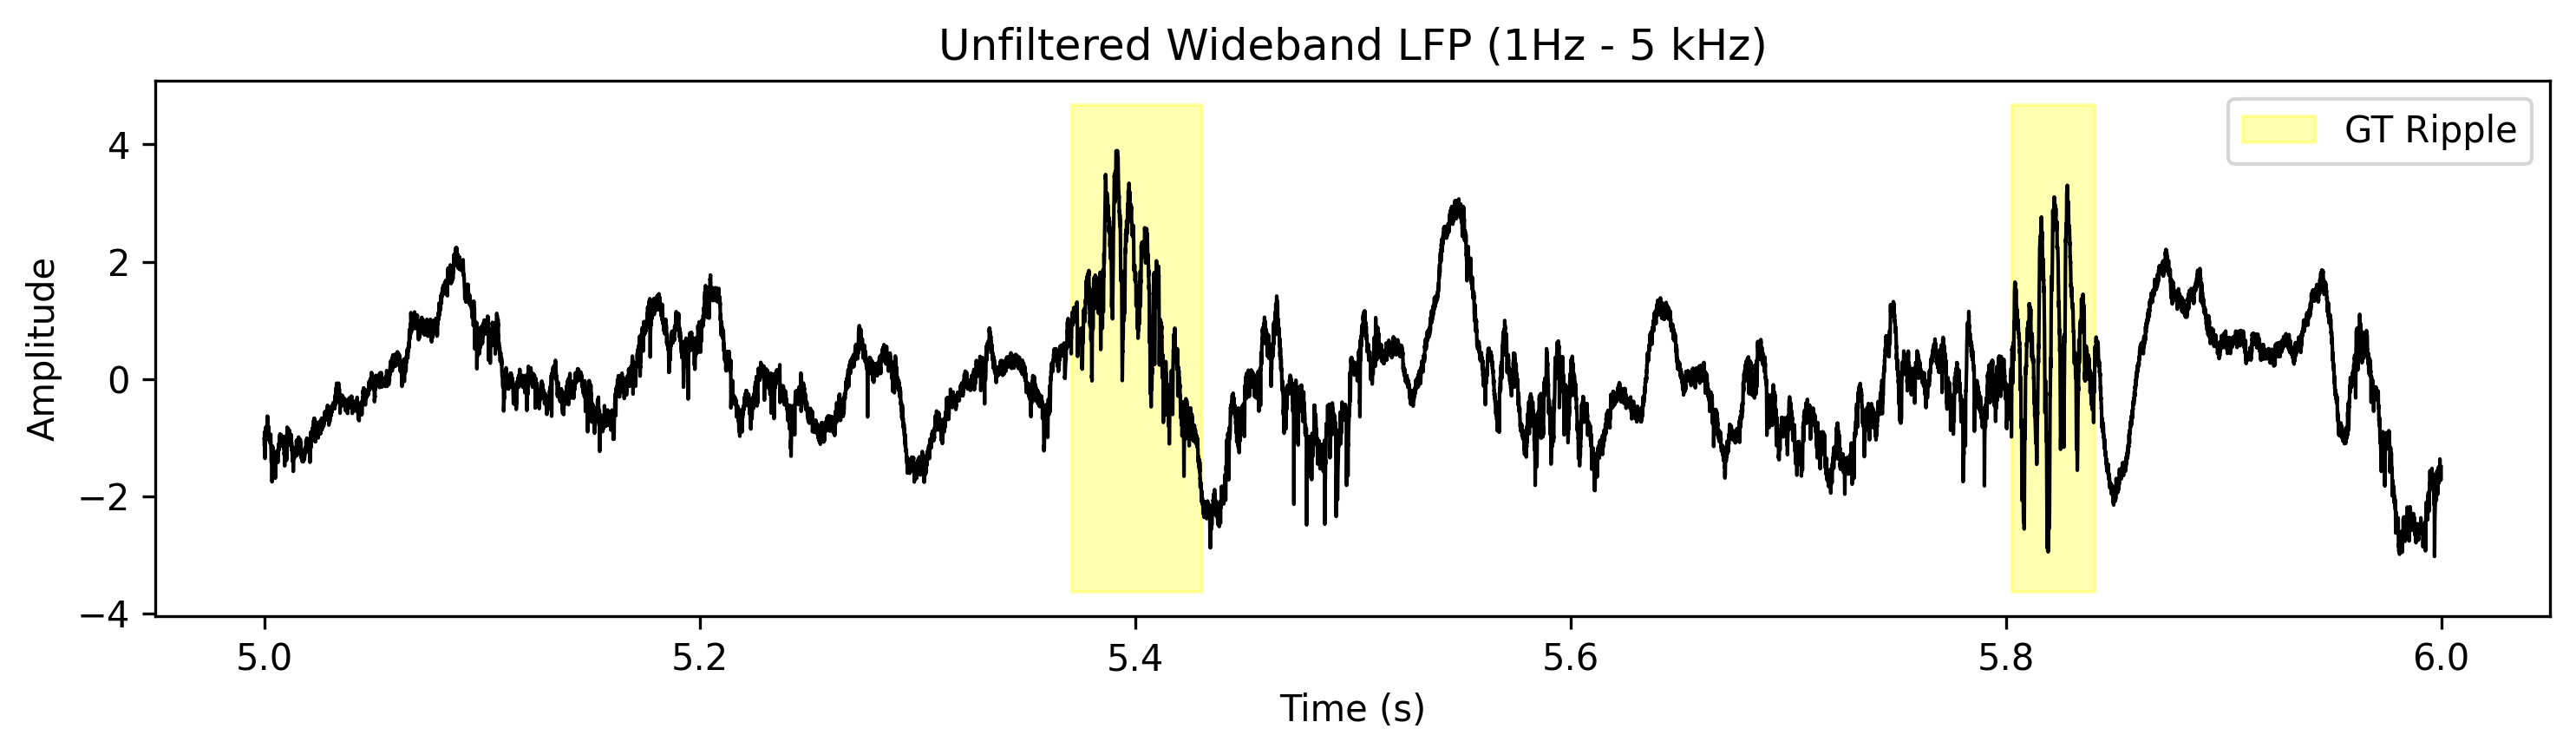

: 

In [ ]:


fig, ax = plt.subplots(figsize=(10, 3), dpi=300)


data = channel_data[window[0]*liset.fs:window[1]*liset.fs]
time = np.arange(window[0]*liset.fs, window[1]*liset.fs) / liset.fs

min_data, max_data = np.min(data), np.max(data)

ax.plot(time, data, label=None, color='black', linewidth=1)

for i,ripple in enumerate(window_ripples):
    start, end = ripple/liset.fs 
    ax.fill_between([start, end],
                    min_data * 1.2, max_data * 1.2,
                    color="yellow", alpha=0.3,label=f"GT Ripple" if i==0 else None)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Unfiltered Wideband LFP (1Hz - 5 kHz)")
ax.legend()
plt.tight_layout()
# plt.savefig("unfiltered_ripples.png", dpi=300)
# plt.show()

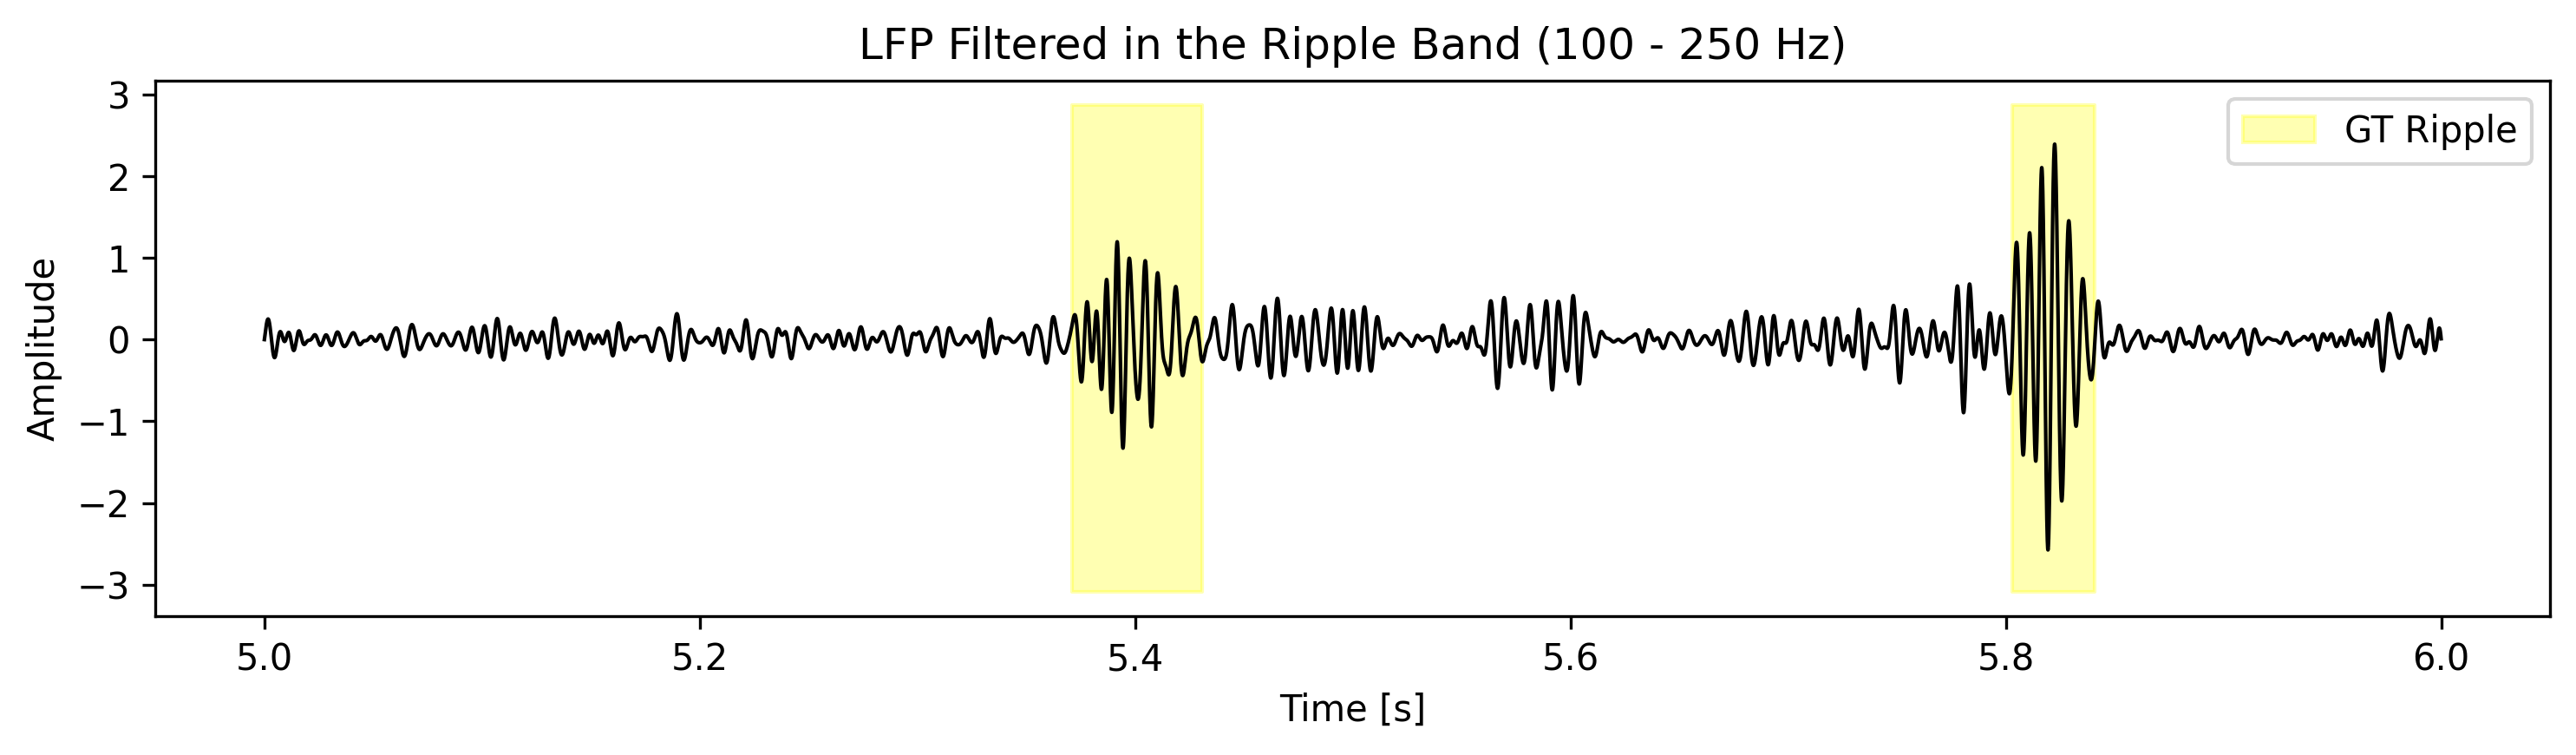

In [80]:

filtered_channel = bandpass_filter(channel_data, fs=liset.fs, bandpass=(100,250), order=4)
filtered_data = filtered_channel[window[0]*liset.fs:window[1]*liset.fs]
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)
time = np.arange(window[0]*liset.fs, window[1]*liset.fs) / liset.fs

min_data, max_data = np.min(filtered_data), np.max(filtered_data)

ax.plot(time, filtered_data, label=None, color='black', linewidth=1)

for i,ripple in enumerate(window_ripples):
    start, end = ripple/liset.fs 
    ax.fill_between([start, end],
                    min_data * 1.2, max_data * 1.2,
                    color="yellow", alpha=0.3,label=f"GT Ripple" if i==0 else None)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("LFP Filtered in the Ripple Band (100 - 250 Hz)")
ax.legend()
plt.tight_layout()

In [81]:
from extract_Nripples.utils_encoding import *
threshold=calculate_threshold(filtered_channel[:120*liset.fs],liset.fs,0.1,0.25,1,plot=False,verbose=False)
print(f"Threshold: {threshold}")
up_down=up_down_channel(filtered_channel,threshold,liset.fs,refractory=0,initial_value=None,return_value=False)


Threshold: 0.37149542253581186


In [93]:
print(f"Up Spikes: {len(up_down[up_down[:,0]>0])}, Down Spikes: {len(up_down[up_down[:,1]>0])}")

Up Spikes: 42511, Down Spikes: 42526


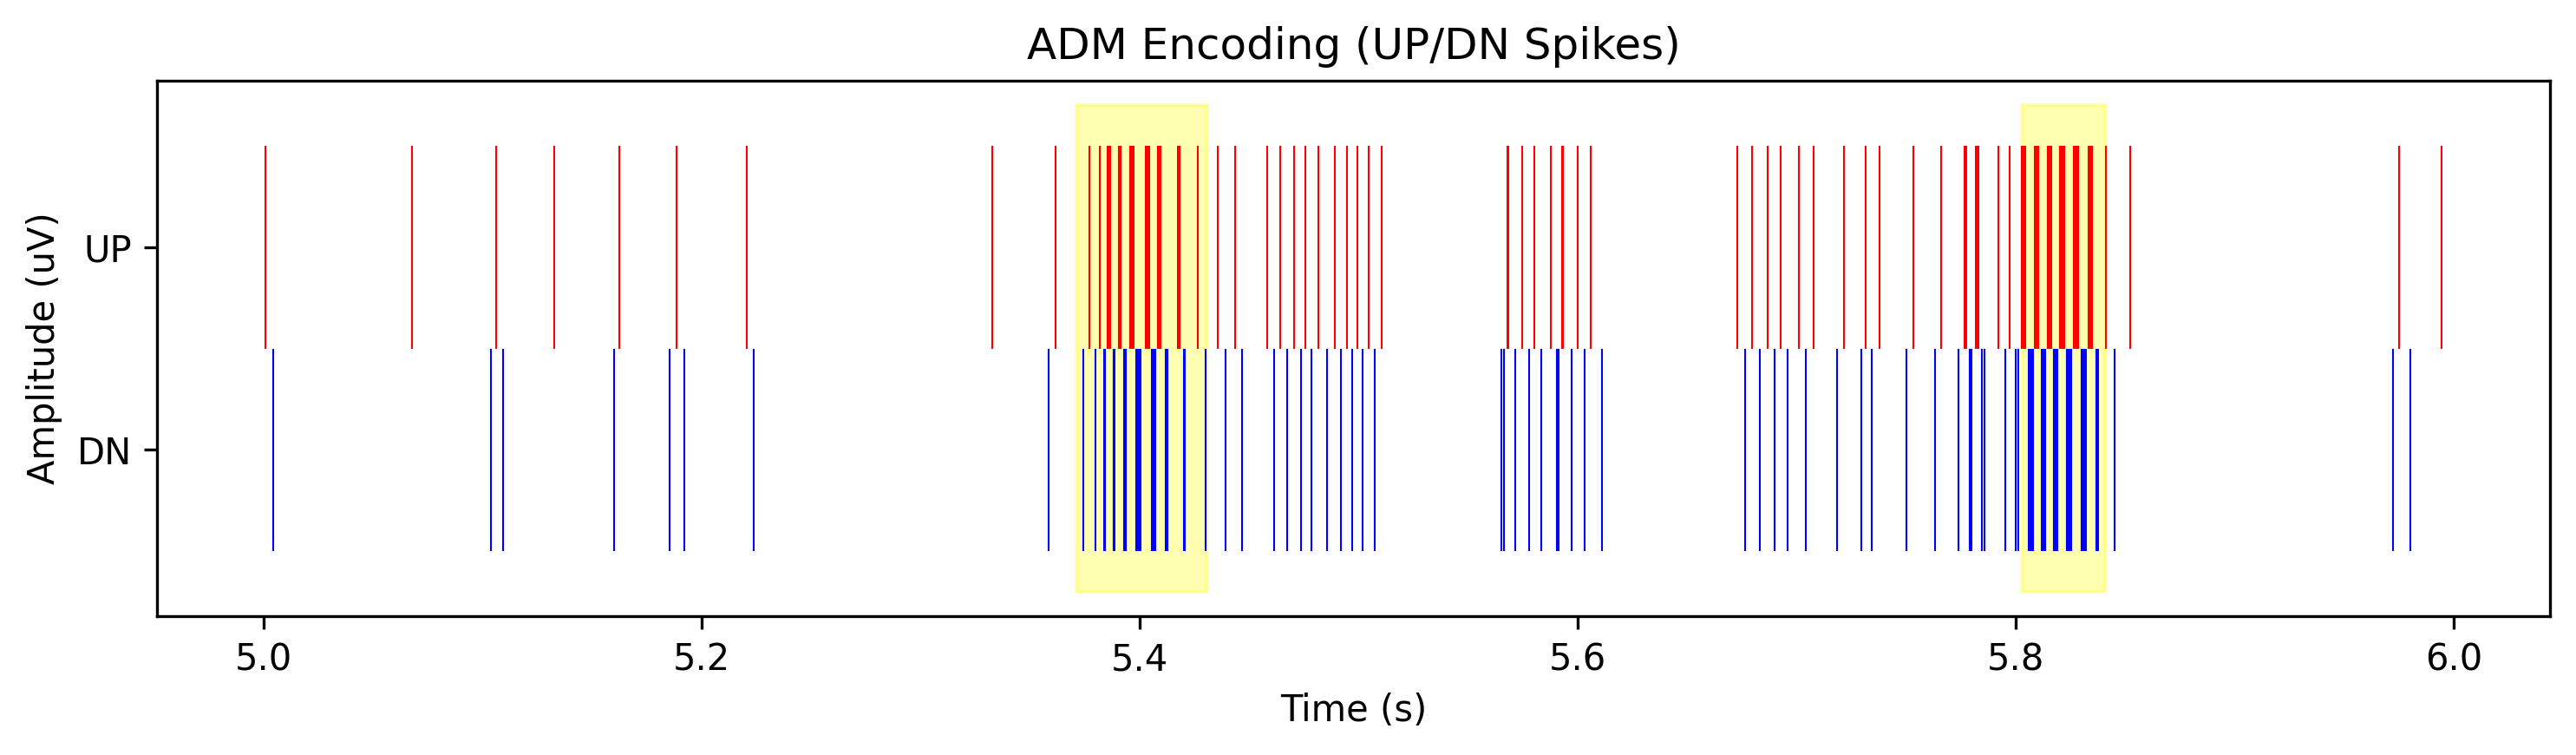

In [119]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)
time = np.arange(window[0]*liset.fs, window[1]*liset.fs) / liset.fs

min_data, max_data = np.min(filtered_data), np.max(filtered_data)
up_down_window= up_down[window[0]*liset.fs:window[1]*liset.fs,:]

up_mask= up_down_window[:,0]>0
down_mask= up_down_window[:,1]>0
# Get the sample indices and convert to time
up_spike_times = time[up_mask]
down_spike_times = time[down_mask]
# ax.plot(time, filtered_data, label=None, color='black', linewidth=1)

# ax.plot(time, filtered_data, label=None, color='black', linewidth=1)
ax.vlines(up_spike_times, ymin=0, ymax=1, color='red', linewidth=0.5,)
ax.vlines(down_spike_times, ymin=-1, ymax=0, color='blue', linewidth=0.5,)

for i,ripple in enumerate(window_ripples):
    start, end = ripple/liset.fs 
    ax.fill_between([start, end],
                    -1.2, 1.2,
                    color="yellow", alpha=0.3,label=f"GT Ripple" if i==0 else None)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title("ADM Encoding (UP/DN Spikes)")
ax.set_yticks([-1/2,1/2],labels=["DN","UP"])
# ax.legend()
plt.tight_layout()

In [89]:
spikes_downsample,spikes_lost=extract_spikes_downsample(up_down,30,)
print(spikes_downsample.shape)

(1036253, 2)


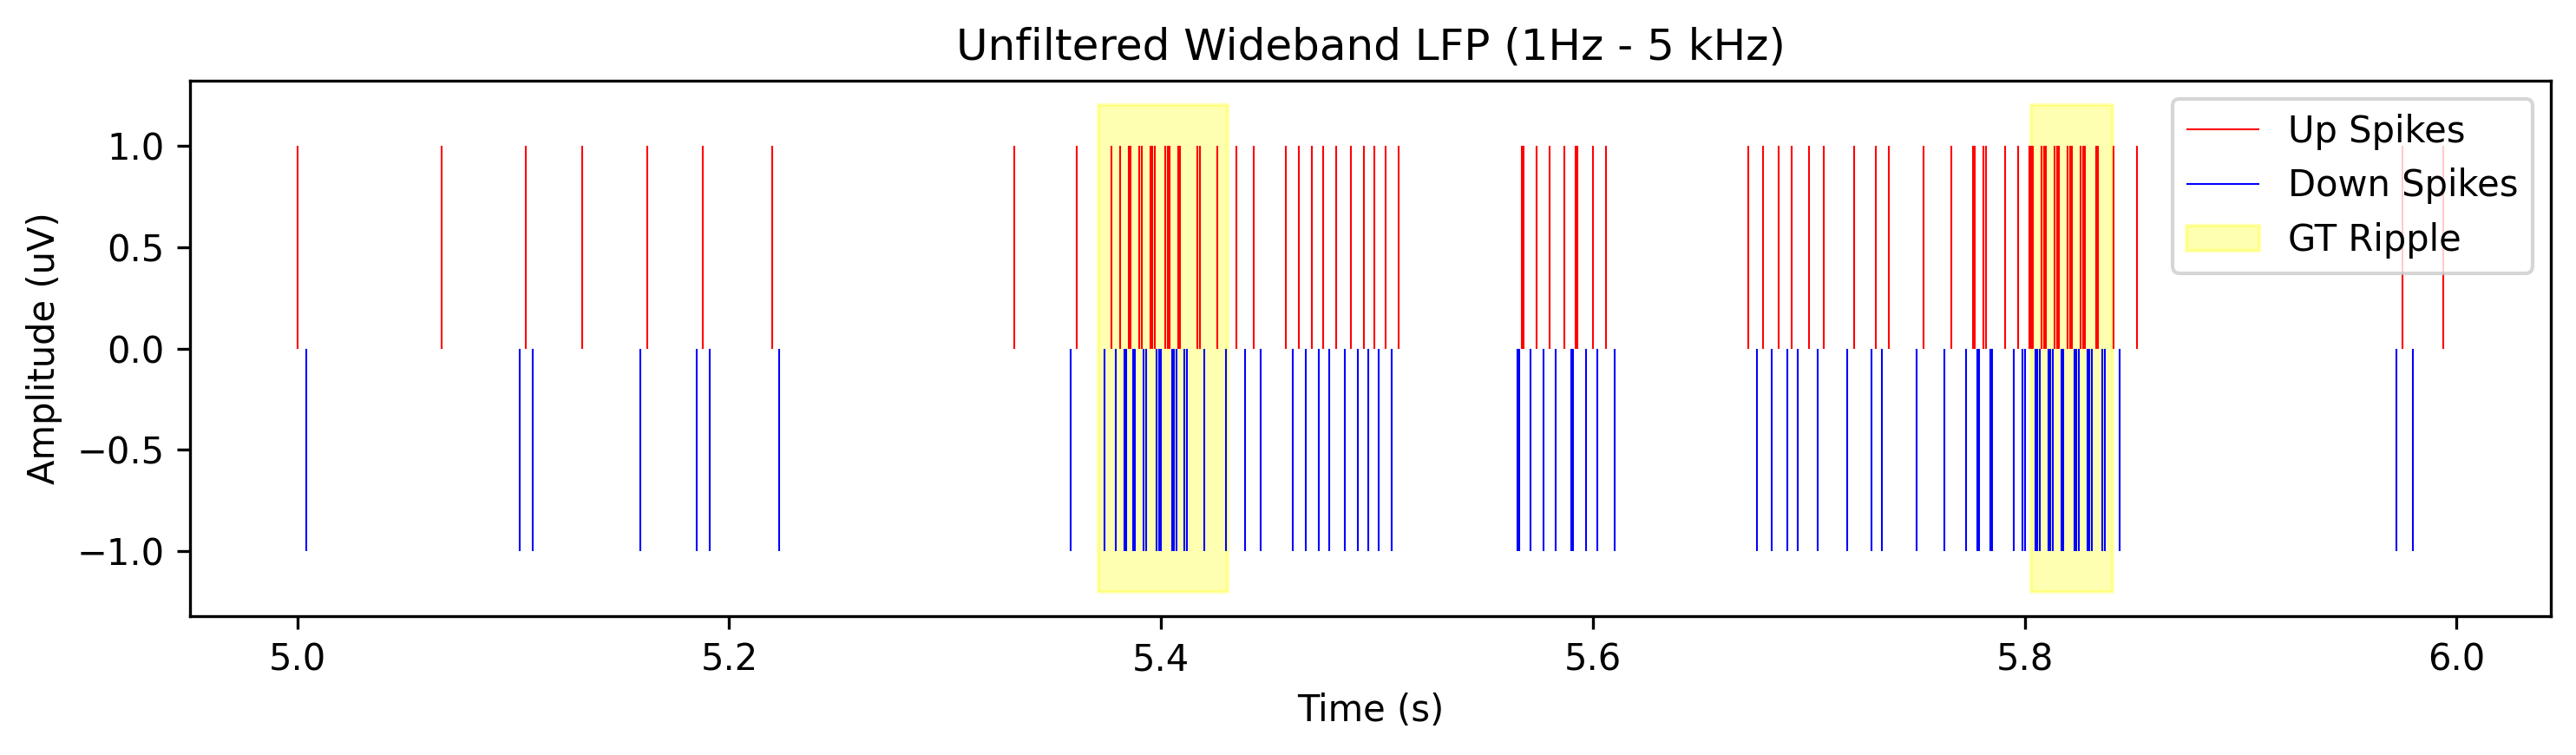

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)
time = np.arange(window[0]*1000, window[1]*1000) / 1000
spikes_downsample_window = spikes_downsample[window[0]*1000:window[1]*1000,:]
spikes_up_mask= spikes_downsample_window[:,0]>0
spikes_down_mask= spikes_downsample_window[:,1]>0
# Get the sample indices and convert to time
up_spike_times = time[spikes_up_mask]
down_spike_times = time[spikes_down_mask]
# ax.plot(time, filtered_data, label=None, color='black', linewidth=1)
ax.vlines(up_spike_times, ymin=0, ymax=1, color='red', linewidth=0.5, label="Up Spikes")
ax.vlines(down_spike_times, ymin=-1, ymax=0, color='blue', linewidth=0.5, label="Down Spikes")

for i,ripple in enumerate(window_ripples):
    start, end = ripple/liset.fs 
    ax.fill_between([start, end],
                    -1.2, 1.2,
                    color="yellow", alpha=0.3,label=f"GT Ripple" if i==0 else None)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title("Unfiltered Wideband LFP (1Hz - 5 kHz)")
ax.set_yticks([-1/2,1/2],labels=["DN","UP"])

ax.legend()
plt.tight_layout()

[[5.3712     5.43083333]
 [5.80286667 5.84083333]]


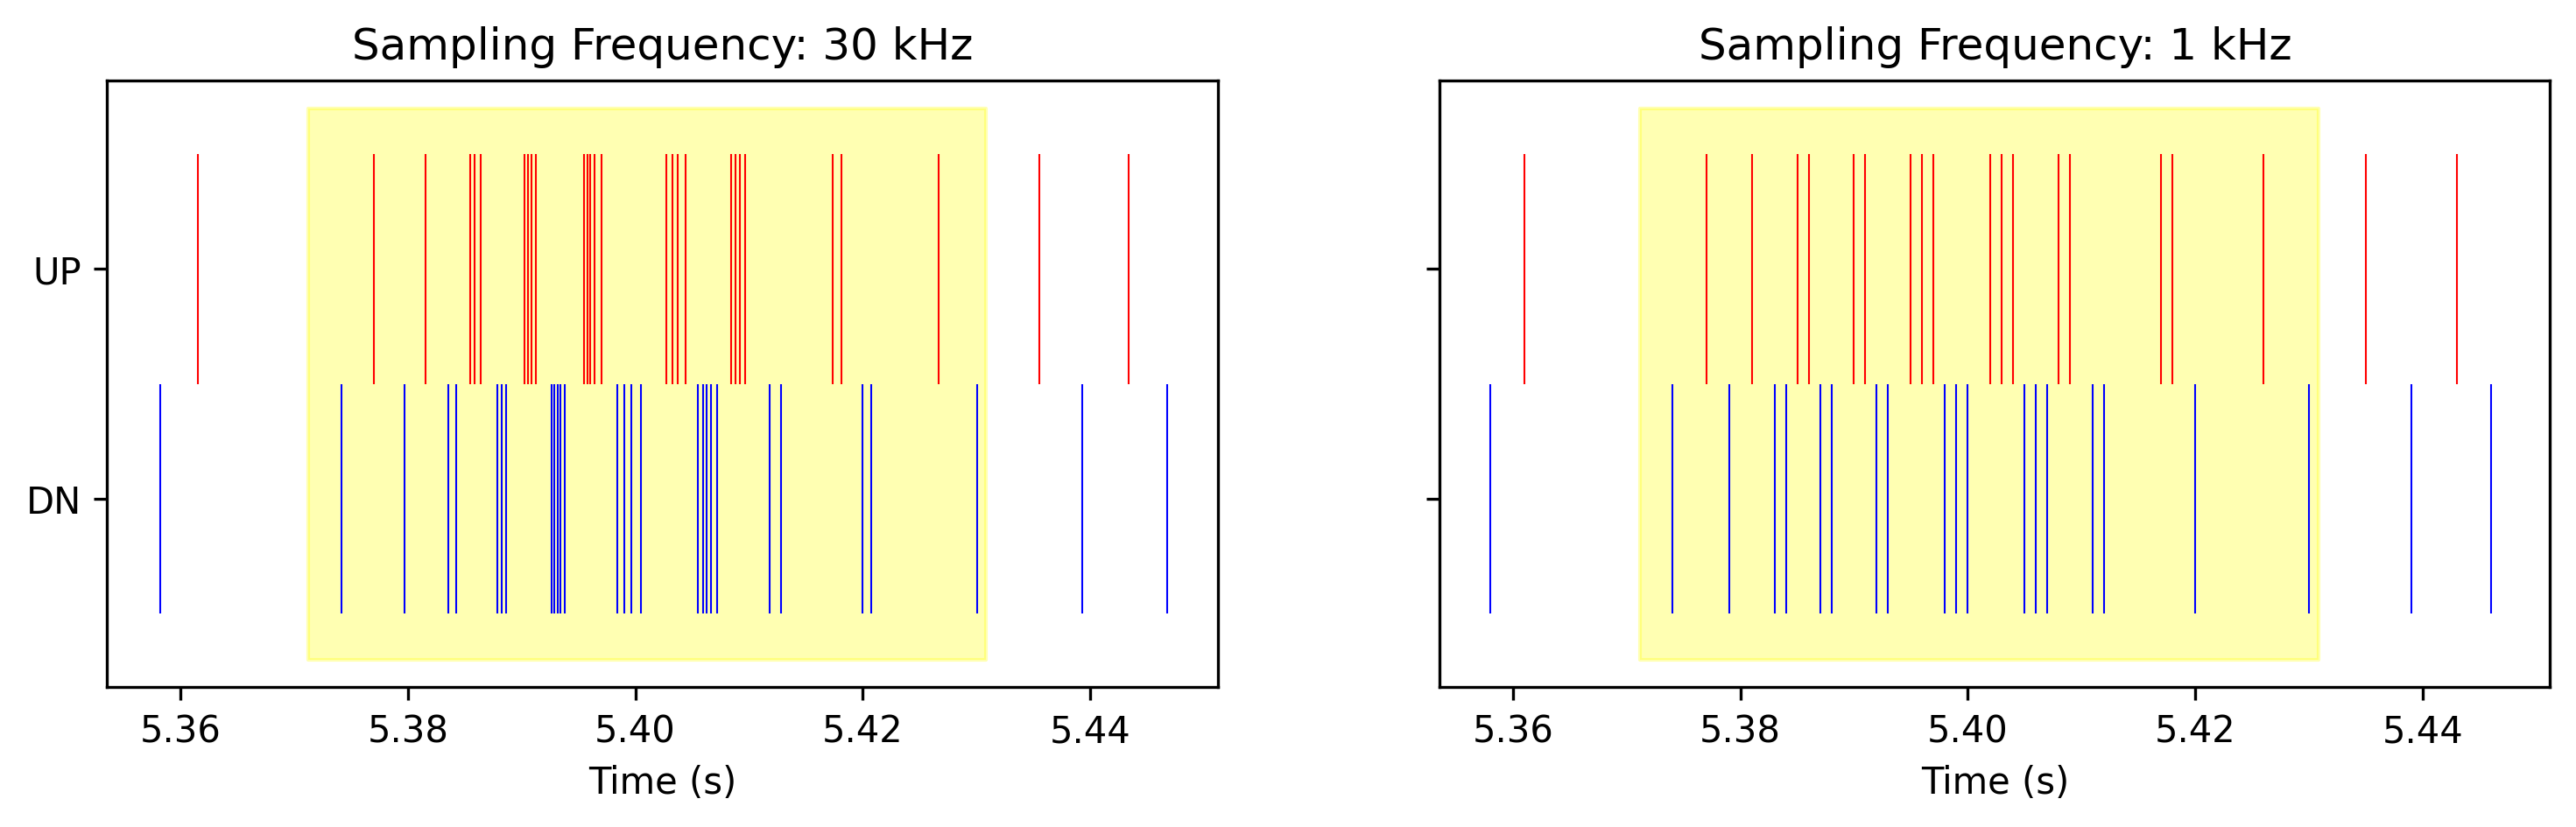

In [116]:
print(window_ripples/liset.fs)
window_downsample=[5.35,5.45]
up_down_window_downsample=up_down[int(window_downsample[0]*liset.fs):int(window_downsample[1]*liset.fs),:]
up_down_ds_window_downsample=spikes_downsample[int(window_downsample[0]*1000):int(window_downsample[1]*1000),:]
fig, axes = plt.subplots(1,2,figsize=(12,3), dpi=300,sharey=True, sharex=True)

ax=axes[0]
time= np.arange(window_downsample[0]*liset.fs, window_downsample[1]*liset.fs) / liset.fs
spikes_up_mask= up_down_window_downsample[:,0]>0
spikes_down_mask= up_down_window_downsample[:,1]>0
# Get the sample indices and convert to time
up_spike_times = time[spikes_up_mask]
down_spike_times = time[spikes_down_mask]
# ax.plot(time, filtered_data, label=None, color='black', linewidth=1)
ax.vlines(up_spike_times, ymin=0, ymax=1, color='red', linewidth=0.5, label="Up Spikes")
ax.vlines(down_spike_times, ymin=-1, ymax=0, color='blue', linewidth=0.5, label="Down Spikes")
start, end = window_ripples[0]/liset.fs 
ax.fill_between([start, end],
                -1.2, 1.2,
                color="yellow", alpha=0.3,label=f"GT Ripple" if i==0 else None)
ax.set_xlabel("Time (s)")
# ax.set_ylabel()
ax.set_title("Sampling Frequency: 30 kHz")
ax.set_yticks([-1/2,1/2],labels=["DN","UP"])

ax=axes[1]
time= np.arange(window_downsample[0]*1000, window_downsample[1]*1000) / 1000
spikes_up_mask= up_down_ds_window_downsample[:,0]>0
spikes_down_mask=up_down_ds_window_downsample[:,1]>0
# Get the sample indices and convert to time
up_spike_times = time[spikes_up_mask]
down_spike_times = time[spikes_down_mask]
# ax.plot(time, filtered_data, label=None, color='black', linewidth=1)
ax.vlines(up_spike_times, ymin=0, ymax=1, color='red', linewidth=0.5, label="Up Spikes")
ax.vlines(down_spike_times, ymin=-1, ymax=0, color='blue', linewidth=0.5, label="Down Spikes")
start, end = window_ripples[0]/liset.fs
ax.fill_between([start, end],
                -1.2, 1.2,
                color="yellow", alpha=0.3,label=f"GT Ripple" if i==0 else None)
ax.set_xlabel("Time (s)")
# ax.set_ylabel()
ax.set_title("Sampling Frequency: 1 kHz")
ax.set_yticks([-1/2,1/2],labels=["DN","UP"])